In [1]:
# Load necessary Python Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ucmr5_pfoa_pfos.csv")

In [3]:
df.head()

,PWSID,PWSName,Size,FacilityID,FacilityName,FacilityWaterType,SamplePointID,SamplePointName,SamplePointType,CollectionDate,...,Contaminant,MRL,Units,MethodID,AnalyticalResultsSign,AnalyticalResultValue,SampleEventCode,MonitoringRequirement,Region,State
0,010106001,Mashantucket Pequot Water System,L,00006,MPTN WTP,GU,TP1,Entry point to Dist. System,EP,9/27/2023,...,PFOS,0.004,µg/L,EPA 533,<,NaN,SE1,AM,1,01
1,010106001,Mashantucket Pequot Water System,L,00006,MPTN WTP,GU,TP1,Entry point to Dist. System,EP,9/27/2023,...,PFOA,0.004,µg/L,EPA 533,=,0.0074,SE1,AM,1,01
2,010106001,Mashantucket Pequot Water System,L,00006,MPTN WTP,GU,TP1,Entry point to Dist. System,EP,10/10/2023,...,PFOA,0.004,µg/L,EPA 533,<,NaN,SE2,AM,1,01
3,010106001,Mashantucket Pequot Water System,L,00006,MPTN WTP,GU,TP1,Entry point to Dist. System,EP,10/10/2023,...,PFOS,0.004,µg/L,EPA 533,<,NaN,SE2,AM,1,01
4,010106001,Mashantucket Pequot Water System,L,00006,MPTN WTP,GU,TP1,Entry point to Dist. System,EP,2/7/2024,...,PFOS,0.004,µg/L,EPA 533,<,NaN,SE3,AM,1,01


In [4]:
df.sample(10)

,PWSID,PWSName,Size,FacilityID,FacilityName,FacilityWaterType,SamplePointID,SamplePointName,SamplePointType,CollectionDate,...,Contaminant,MRL,Units,MethodID,AnalyticalResultsSign,AnalyticalResultValue,SampleEventCode,MonitoringRequirement,Region,State
42577,IN5249004,CITIZENS WATER - INDIANAPOLIS,L,17703,Treatment Plant #3,SW,EP003,T.W. Moses,EP,8/23/2023,...,PFOA,0.004,µg/L,EPA 533,<,NaN,SE1,AM,5,IN
91079,PR0004474,PIEDRAS BLANCAS,S,00001,PIEDRAS BLANCAS,GW,44740000,PZ PIEDRAS BLANCAS 1,EP,2/20/2024,...,PFOA,0.004,µg/L,EPA 533,<,NaN,SE1,AM,2,PR
30094,FL4130604,"HIALEAH, CITY OF",L,00002,Miami Dade (Preston TP),GW,POE2,1100 W. 2nd Avenue,EP,1/17/2024,...,PFOA,0.004,µg/L,EPA 533,<,NaN,SE2,AM,4,FL
97482,TX0150115,JBSA - RANDOLPH,L,EP002,JBSA - RANDOLPH,GW,TRTTAP,EXT HB WEST SIDE,EP,7/17/2024,...,PFOA,0.004,µg/L,EPA 533,<,NaN,SE1,AM,6,TX
66636,NC0392373,BAYLEAF MASTER,L,70576,Barton Creek Overlook #2,GW,EP012,Entry Point to Dist. System,EP,5/13/2025,...,PFOA,0.004,µg/L,EPA 533,<,NaN,SE2,AM,4,NC
101534,TX0920021,TRYON ROAD SUD,S,EP004,TRYON ROAD SUD Plant 4,MX,EP004,Plant 4 PUMP HOUSE,EP,5/7/2025,...,PFOA,0.004,µg/L,EPA 533,<,NaN,SE2,AM,6,TX
28138,FL1460144,"FORT WALTON BEACH, CITY OF",L,00006,Well #6,GW,0144006,EP Tap @ Well #6,EP,5/20/2025,...,PFOS,0.004,µg/L,EPA 533,<,NaN,SE2,AM,4,FL
4168,AL0001293,"CITIZENS WATER SERVICE, INC.",L,90103,Harmon Well,GW,RT01,Harmon Well,EP,1/9/2025,...,PFOS,0.004,µg/L,EPA 533,<,NaN,SE1,AM,4,AL
19177,CA3610038,"RIALTO, CITY OF",L,00016,SWTP,SW,3610038016,Entry Point to Dist. System,EP,4/24/2024,...,PFOS,0.004,µg/L,EPA 533,<,NaN,SE4,AM,9,CA
56098,MN1040002,Bemidji,L,5,TREATMENT PLANT,GW,E01,TREATMENT PLANT,EP,1/14/2025,...,PFOS,0.004,µg/L,EPA 533,<,NaN,SE2,AM,5,MN


In [5]:
df.shape

(121260, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121260 entries, 0 to 121259
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   PWSID                  121260 non-null  object 
 1   PWSName                121260 non-null  object 
 2   Size                   121260 non-null  object 
 3   FacilityID             121256 non-null  object 
 4   FacilityName           121256 non-null  object 
 5   FacilityWaterType      121260 non-null  object 
 6   SamplePointID          121260 non-null  object 
 7   SamplePointName        121260 non-null  object 
 8   SamplePointType        121260 non-null  object 
 9   CollectionDate         121260 non-null  object 
 10  SampleID               121260 non-null  object 
 11  Contaminant            121260 non-null  object 
 12  MRL                    121260 non-null  float64
 13  Units                  121260 non-null  object 
 14  MethodID               121260 non-nu

In [7]:
df["FacilityID"].describe()

count     121256
unique      9287
top        00001
freq        5094
Name: FacilityID, dtype: object

In [8]:
df["PWSID"].describe()

count        121260
unique        10257
top       NY5110526
freq            958
Name: PWSID, dtype: object

In [9]:
df.isna().sum()

PWSID                         0
PWSName                       0
Size                          0
FacilityID                    4
FacilityName                  4
FacilityWaterType             0
SamplePointID                 0
SamplePointName               0
SamplePointType               0
CollectionDate                0
SampleID                      0
Contaminant                   0
MRL                           0
Units                         0
MethodID                      0
AnalyticalResultsSign         0
AnalyticalResultValue    113093
SampleEventCode               0
MonitoringRequirement         0
Region                        0
State                         0
dtype: int64

AnalyticalResultsSign Sign indicating whether the analytical result is less than (<) the UCMR 5 MRL or equal to (=) a numeric value at or above the UCMR 5 MRL
AnalyticalResultValue Numeric value of the analytical result in µg/L for the contaminants. Null (or blank) values represent results less than the UCMR 5 MRL

In [10]:
print(df['AnalyticalResultsSign'].value_counts())
print()
print(f"Total Samples: {len(df)}")
print(f"Non-detects: (Analytical Result Value has no value) -> {df['AnalyticalResultValue'].isna().sum()}")
print(f"Detections:(Analytical Result Value has value) -> {df['AnalyticalResultValue'].notna().sum()}")
print(f"Detection rate: {(df['AnalyticalResultValue'].notna().sum() / len(df)) * 100:.2f}%")

AnalyticalResultsSign
<    113093
=      8167
Name: count, dtype: int64

Total Samples: 121260
Non-detects: (Analytical Result Value has no value) -> 113093
Detections:(Analytical Result Value has value) -> 8167
Detection rate: 6.74%


In [11]:
int(df["FacilityID"].isna().sum())

4

PWSID NV0000167 was removed cause the Facility ID was missing

In [12]:
int(df["FacilityName"].isna().sum())

4

In [13]:
df[df["FacilityID"].isna()]

,PWSID,PWSName,Size,FacilityID,FacilityName,FacilityWaterType,SamplePointID,SamplePointName,SamplePointType,CollectionDate,...,Contaminant,MRL,Units,MethodID,AnalyticalResultsSign,AnalyticalResultValue,SampleEventCode,MonitoringRequirement,Region,State
74840,NV0000167,VIRGIN VALLEY WATER DISTRICT,L,NaN,Treatment Plant #1A (TP1A),GW,16,Entry Point to Dist. System,EP,10/3/2023,...,PFOA,0.004,µg/L,EPA 533,<,NaN,SE1,AM,9,NV
74841,NV0000167,VIRGIN VALLEY WATER DISTRICT,L,NaN,Treatment Plant #1A (TP1A),GW,16,Entry Point to Dist. System,EP,10/3/2023,...,PFOS,0.004,µg/L,EPA 533,<,NaN,SE1,AM,9,NV
74842,NV0000167,VIRGIN VALLEY WATER DISTRICT,L,NaN,Treatment Plant #1A (TP1A),GW,16,Entry Point to Dist. System,EP,3/26/2024,...,PFOA,0.004,µg/L,EPA 533,<,NaN,SE2,AM,9,NV
74843,NV0000167,VIRGIN VALLEY WATER DISTRICT,L,NaN,Treatment Plant #1A (TP1A),GW,16,Entry Point to Dist. System,EP,3/26/2024,...,PFOS,0.004,µg/L,EPA 533,<,NaN,SE2,AM,9,NV


In [14]:
df.loc[df["FacilityID"].isna(), "PWSID"]

74840    NV0000167
74841    NV0000167
74842    NV0000167
74843    NV0000167
Name: PWSID, dtype: object

In [15]:
df[df["FacilityName"].isna()]

,PWSID,PWSName,Size,FacilityID,FacilityName,FacilityWaterType,SamplePointID,SamplePointName,SamplePointType,CollectionDate,...,Contaminant,MRL,Units,MethodID,AnalyticalResultsSign,AnalyticalResultValue,SampleEventCode,MonitoringRequirement,Region,State
41240,IL1970500,LOCKPORT,L,IL1970500,NaN,GW,TP16,WELL 15 FINISHED WATER,EP,12/19/2023,...,PFOA,0.004,µg/L,EPA 533,<,NaN,SE1,AM,5,IL
41241,IL1970500,LOCKPORT,L,IL1970500,NaN,GW,TP16,WELL 15 FINISHED WATER,EP,12/19/2023,...,PFOS,0.004,µg/L,EPA 533,<,NaN,SE1,AM,5,IL
41242,IL1970500,LOCKPORT,L,IL1970500,NaN,GW,TP16,WELL 15 FINISHED WATER,EP,8/28/2024,...,PFOA,0.004,µg/L,EPA 533,<,NaN,SE2,AM,5,IL
41243,IL1970500,LOCKPORT,L,IL1970500,NaN,GW,TP16,WELL 15 FINISHED WATER,EP,8/28/2024,...,PFOS,0.004,µg/L,EPA 533,<,NaN,SE2,AM,5,IL


PWSID IL1970500	 had Facility Name missing but Facility ID was present, so didn't remove this.

In [16]:
df = df.dropna(subset=["FacilityID"]).reset_index(drop=True)

In [17]:
len(df)

121256

In [18]:
df['PWSID'].nunique()

10257

In [19]:
# Create Concentration column: detected values stay as-is; non-detects (NaN) replaced with 0
df['Concentration'] = df['AnalyticalResultValue'].fillna(0)

In [20]:
# Compute the average PFAS concentration at each entry point (PWSID + FacilityID)
# separately for each contaminant (PFOA and PFOS)
ep_avg = (
    df.groupby(["PWSID", "FacilityID", "Contaminant"])["Concentration"]
    .mean()
    .reset_index()
)
ep_avg

,PWSID,FacilityID,Contaminant,Concentration
0,010106001,00006,PFOA,0.005275
1,010106001,00006,PFOS,0.000000
2,010109005,90001,PFOA,0.000000
3,010109005,90001,PFOS,0.000000
4,020000005,EP001,PFOA,0.000000
...,...,...,...,...
52617,WY5680085,TP01,PFOS,0.000000
52618,WY5680095,TP02,PFOA,0.000000
52619,WY5680095,TP02,PFOS,0.000000
52620,WY5680122,20001,PFOA,0.000000


In [21]:
# Reshape the entry-point–level data so that each row represents one entry point
# (PWSID + FacilityID), with separate columns for average PFOA and PFOS concentrations
ep_table = (
    ep_avg
    .pivot(
        index = ['PWSID','FacilityID'],
        columns = 'Contaminant', values = 'Concentration'
    )
    .reset_index()
)
ep_table.columns.name = None

In [22]:
ep_table

,PWSID,FacilityID,PFOA,PFOS
0,010106001,00006,0.005275,0.0
1,010109005,90001,0.000000,0.0
2,020000005,EP001,0.000000,0.0
3,020000008,GW001,0.000000,0.0
4,020000008,SW001,0.000000,0.0
...,...,...,...,...
26306,WY5601569,TP02,0.000000,0.0
26307,WY5680074,TP01,0.000000,0.0
26308,WY5680085,TP01,0.000000,0.0
26309,WY5680095,TP02,0.000000,0.0


In [23]:
# Set threshold at 80% of 0.004 µg/L (i.e., 0.0032)
threshold = 0.004 * 0.8  # 0.0032

# Flag where max PFOA or PFOS concentration exceeds threshold
ep_table["exceeds"] = (
    (ep_table["PFOA"] > threshold) |
    (ep_table["PFOS"] > threshold)
)


In [24]:
# no. of PWSID
ep_table['PWSID'].nunique()

10257

In [25]:
ep_table.head(20)

,PWSID,FacilityID,PFOA,PFOS,exceeds
0,010106001,00006,0.005275,0.0,True
1,010109005,90001,0.000000,0.0,False
2,020000005,EP001,0.000000,0.0,False
3,020000008,GW001,0.000000,0.0,False
4,020000008,SW001,0.000000,0.0,False
5,040000002,TP201,0.000000,0.0,False
6,040000002,TP202,0.000000,0.0,False
7,043740039,37407,0.000000,0.0,False
8,050593203,02018,0.000000,0.0,False
9,055293201,00051,0.000000,0.0,False


In [26]:
total_exceeding_facilities = ep_table["exceeds"].sum()

print(f"Total entry points: {len(ep_table)}")
print(f"Entry points exceeding threshold: {total_exceeding_facilities}")
print(f"Percentage: {total_exceeding_facilities / len(ep_table) * 100:.1f}%")

Total entry points: 26311
Entry points exceeding threshold: 2217
Percentage: 8.4%


### Merge UCMR5 with SDWA for Population Serve Count

In [27]:
sdwa = pd.read_excel("../SDWA_PUB_WATER_SYSTEMS.xlsx")

In [28]:
sdwa.head()

,SUBMISSIONYEARQUARTER,PWSID,PWS_NAME,PRIMACY_AGENCY_CODE,EPA_REGION,SEASON_BEGIN_DATE,SEASON_END_DATE,PWS_ACTIVITY_CODE,PWS_DEACTIVATION_DATE,PWS_TYPE_CODE,...,LAST_REPORTED_DATE,STATE_CODE,SOURCE_WATER_PROTECTION_CODE,SOURCE_PROTECTION_BEGIN_DATE,OUTSTANDING_PERFORMER,OUTSTANDING_PERFORM_BEGIN_DATE,REDUCED_RTCR_MONITORING,REDUCED_MONITORING_BEGIN_DATE,REDUCED_MONITORING_END_DATE,SEASONAL_STARTUP_SYSTEM
0,2025Q2,WA5325264,HANNAH HEIGHTS #2 WATER USERS ASSN,WA,10,NaT,NaT,A,NaT,CWS,...,2025-06-27,WA,NaN,NaT,Y,2024-06-12,NaN,NaT,NaT,NaN
1,2025Q2,LA1119034,GIL-GAL WATER SYSTEM,LA,6,NaT,NaT,A,NaT,CWS,...,2025-06-18,LA,N,NaT,NaN,NaT,NaN,NaT,NaT,NaN
2,2025Q2,NC0120414,THE MOUNTAIN FOLK CENTER,NC,4,2025-01-01,2025-12-31,A,NaT,TNCWS,...,2025-06-26,NC,NaN,NaT,NaN,NaT,NaN,NaT,NaT,NaN
3,2025Q2,AZ0413182,THAI GARDENS,AZ,9,2025-01-01,2025-12-31,A,NaT,TNCWS,...,2025-06-30,AZ,N,NaT,NaN,NaT,NaN,NaT,NaT,NaN
4,2025Q2,LA1073003,BETTER WATERWORKS WATER SYSTEM,LA,6,NaT,NaT,A,NaT,CWS,...,2025-06-18,LA,N,NaT,NaN,NaT,NaN,NaT,NaT,NaN


In [29]:
sdwa.isna().sum()

SUBMISSIONYEARQUARTER                  0
PWSID                                  0
PWS_NAME                             897
PRIMACY_AGENCY_CODE                    0
EPA_REGION                             0
SEASON_BEGIN_DATE                  63559
SEASON_END_DATE                    63559
PWS_ACTIVITY_CODE                      0
PWS_DEACTIVATION_DATE             143268
PWS_TYPE_CODE                          0
DBPR_SCHEDULE_CAT_CODE            395191
CDS_ID                            416626
GW_SW_CODE                          3267
LT2_SCHEDULE_CAT_CODE             430184
OWNER_TYPE_CODE                    49287
POPULATION_SERVED_COUNT                0
POP_CAT_2_CODE                         0
POP_CAT_3_CODE                         0
POP_CAT_4_CODE                         0
POP_CAT_5_CODE                         0
POP_CAT_11_CODE                        0
PRIMACY_TYPE                           0
PRIMARY_SOURCE_CODE                 3267
IS_GRANT_ELIGIBLE_IND                  0
IS_WHOLESALER_IN

In [30]:
# Created a new table ep_table_with_pop by merging ep_table with population served data from sdwa using PWSID
ep_table_with_pop = ep_table.merge(sdwa[['PWSID', 'POPULATION_SERVED_COUNT']], on = 'PWSID', how = 'left')

In [31]:
# total length of the ep_table_with_pop
len(ep_table_with_pop)

26311

In [32]:
ep_table_with_pop.isna().sum()

PWSID                        0
FacilityID                   0
PFOA                         0
PFOS                         0
exceeds                      0
POPULATION_SERVED_COUNT    163
dtype: int64

In [33]:
# Identify systems that are missing population data to check coverage of the SDWA merge 
missing_population = ep_table_with_pop.loc[ep_table_with_pop['POPULATION_SERVED_COUNT'].isna()]
missing_population.head()

,PWSID,FacilityID,PFOA,PFOS,exceeds,POPULATION_SERVED_COUNT
0,010106001,00006,0.005275,0.0,True,NaN
1,010109005,90001,0.000000,0.0,False,NaN
2,020000005,EP001,0.000000,0.0,False,NaN
3,020000008,GW001,0.000000,0.0,False,NaN
4,020000008,SW001,0.000000,0.0,False,NaN


In [34]:
missing_population['PWSID'].nunique()

102

In [35]:
missing_population.loc[missing_population['exceeds']]

,PWSID,FacilityID,PFOA,PFOS,exceeds,POPULATION_SERVED_COUNT
0,010106001,00006,0.005275,0.00000,True,NaN
116,090600147,EP004,0.002800,0.00445,True,NaN
139,090605153,90005,0.005650,0.00000,True,NaN


ZIPCODE of the PWSID that exceeds the 80% threshold of PFOA or PFOS but has the POPULATION SERVE COUNT MISSING:

    PWSID         ZIP
    010106001 -> 06338
    090600147 -> 92082
    090605013 -> 92593

In [36]:
ep_table_with_pop.loc[
    ep_table_with_pop["PWSID"].isin(
        missing_population.loc[missing_population["exceeds"], "PWSID"].unique()
    ),
    ["PWSID", "FacilityID", "exceeds"]
].sort_values(["PWSID", "FacilityID"])


,PWSID,FacilityID,exceeds
0,010106001,00006,True
114,090600147,EP002,False
115,090600147,EP003,False
116,090600147,EP004,True
136,090605153,90001,False
137,090605153,90002,False
138,090605153,90004,False
139,090605153,90005,True


Missing Population Data and PWSID Mapping

When the UCMR5 entry-point PFAS data were merged with SDWA Public Water System data to add population served (POPULATION_SERVED_COUNT), some entry points could not be assigned population values. This occurred because the corresponding PWSIDs were not present in the SDWA dataset.

A Public Water System Identification Code (PWSID) uniquely identifies each water system. Most PWSIDs begin with a two-letter state abbreviation followed by numbers. However, some systems in UCMR5 use different formats, including tribal and regional identifiers. For example, systems with PWSIDs beginning with NN (Navajo Nation) appear in UCMR5 but are not included in SDWA population records. Utah systems also use a special format that begins with UTAH.

Because the SDWA population dataset relies on state-based PWSID formats, these regional and tribal PWSIDs could not be matched, resulting in missing population values for all entry points within those systems.

In this analysis, population was allocated at the entry-point level by evenly dividing system population across entry points. For systems without population data in SDWA, population could not be assigned to their entry points. These entry points were excluded from population-weighted analyses but retained for exceedance counts and other entry-point summaries.

Overall, fewer than 1% of systems lacked population served information. Given the small number of affected systems, excluding them from population-based analyses does not meaningfully affect the results. If needed, population information for these systems could be estimated in future work using ZIP-code–based datasets.

In [37]:
# removed rows with missing population serve count
ep_table_with_pop = ep_table_with_pop.dropna(subset = ['POPULATION_SERVED_COUNT']).reset_index(drop=True)

In [38]:
ep_table_with_pop

,PWSID,FacilityID,PFOA,PFOS,exceeds,POPULATION_SERVED_COUNT
0,AK2110342,29349,0.0,0.0,False,38526.0
1,AK2110342,29360,0.0,0.0,False,38526.0
2,AK2110601,10001,0.0,0.0,False,10947.0
3,AK2110601,10004,0.0,0.0,False,10947.0
4,AK2120232,TP001,0.0,0.0,False,8937.0
...,...,...,...,...,...,...
26143,WY5601569,TP02,0.0,0.0,False,580.0
26144,WY5680074,TP01,0.0,0.0,False,4300.0
26145,WY5680085,TP01,0.0,0.0,False,7675.0
26146,WY5680095,TP02,0.0,0.0,False,4514.0


### Entry-Point Population Allocation and Population Binning

To analyze PFAS at the entry-point level, the population served by each water system was split across its entry points. First, we counted how many entry points each system has by counting unique FacilityID values for each PWSID. The total system population was then divided evenly across those entry points.

The assigned population for each entry point (Ep_Population) was added back to the entry-point PFAS dataset so that each row represents one entry point with an estimated population served. Finally, entry points were grouped into population size categories using the assign_pop_bin() function, ensuring that population binning is based on entry points rather than entire water systems for all further analysis.

In [39]:
ep_counts = (
    ep_table_with_pop
    .groupby("PWSID")["FacilityID"]
    .nunique()
    .reset_index(name="n_entry_points")
)

ep_counts.sample(10)


,PWSID,n_entry_points
130,AL0000566,5
487,AR0000688,6
7573,RI1559518,1
6819,OK1020506,1
2904,IL1350300,1
10051,WV3302016,1
9682,WA5341600,1
6778,OH8504512,1
1696,FL2040372,1
2725,IL0435350,1


In [40]:
ep_with_population = (
    ep_table_with_pop[["PWSID", "FacilityID", "POPULATION_SERVED_COUNT"]]
    .drop_duplicates()
    .merge(ep_counts, on="PWSID", how="left")
)
ep_with_population

,PWSID,FacilityID,POPULATION_SERVED_COUNT,n_entry_points
0,AK2110342,29349,38526.0,2
1,AK2110342,29360,38526.0,2
2,AK2110601,10001,10947.0,2
3,AK2110601,10004,10947.0,2
4,AK2120232,TP001,8937.0,1
...,...,...,...,...
26143,WY5601569,TP02,580.0,1
26144,WY5680074,TP01,4300.0,1
26145,WY5680085,TP01,7675.0,1
26146,WY5680095,TP02,4514.0,1


In [41]:
ep_with_population['Ep_Population'] = (
    ep_with_population['POPULATION_SERVED_COUNT']/ep_with_population['n_entry_points']
)
ep_with_population

,PWSID,FacilityID,POPULATION_SERVED_COUNT,n_entry_points,Ep_Population
0,AK2110342,29349,38526.0,2,19263.0
1,AK2110342,29360,38526.0,2,19263.0
2,AK2110601,10001,10947.0,2,5473.5
3,AK2110601,10004,10947.0,2,5473.5
4,AK2120232,TP001,8937.0,1,8937.0
...,...,...,...,...,...
26143,WY5601569,TP02,580.0,1,580.0
26144,WY5680074,TP01,4300.0,1,4300.0
26145,WY5680085,TP01,7675.0,1,7675.0
26146,WY5680095,TP02,4514.0,1,4514.0


In [42]:
ep_table_final = ep_table_with_pop.merge(
    ep_with_population[["PWSID", "FacilityID", "Ep_Population"]],
    on=["PWSID", "FacilityID"],
    how="left"
)

ep_table_final.head()


,PWSID,FacilityID,PFOA,PFOS,exceeds,POPULATION_SERVED_COUNT,Ep_Population
0,AK2110342,29349,0.0,0.0,False,38526.0,19263.0
1,AK2110342,29360,0.0,0.0,False,38526.0,19263.0
2,AK2110601,10001,0.0,0.0,False,10947.0,5473.5
3,AK2110601,10004,0.0,0.0,False,10947.0,5473.5
4,AK2120232,TP001,0.0,0.0,False,8937.0,8937.0


In [43]:
def assign_pop_bin(pop):
    if pop <= 100:
        return '25 - 100'
    elif pop <= 500:
        return '101 - 500'
    elif pop <= 1000:
        return '501 - 1,000'
    elif pop <= 3300:
        return '1,001 - 3,300'
    elif pop <= 10000:
        return '3,301 - 10,000'
    elif pop <= 50000:
        return '10,001 - 50,000'
    elif pop <= 100000:
        return '50,001 - 100,000'
    elif pop <= 1000000:
        return '100,001 - 1,000,000'
    else:
        return '> 1,000,000'

In [44]:
ep_table_final['Population_bin'] = ep_table_final['Ep_Population'].apply(assign_pop_bin)

In [45]:
ep_table_final

,PWSID,FacilityID,PFOA,PFOS,exceeds,POPULATION_SERVED_COUNT,Ep_Population,Population_bin
0,AK2110342,29349,0.0,0.0,False,38526.0,19263.0,"10,001 - 50,000"
1,AK2110342,29360,0.0,0.0,False,38526.0,19263.0,"10,001 - 50,000"
2,AK2110601,10001,0.0,0.0,False,10947.0,5473.5,"3,301 - 10,000"
3,AK2110601,10004,0.0,0.0,False,10947.0,5473.5,"3,301 - 10,000"
4,AK2120232,TP001,0.0,0.0,False,8937.0,8937.0,"3,301 - 10,000"
...,...,...,...,...,...,...,...,...
26143,WY5601569,TP02,0.0,0.0,False,580.0,580.0,"501 - 1,000"
26144,WY5680074,TP01,0.0,0.0,False,4300.0,4300.0,"3,301 - 10,000"
26145,WY5680085,TP01,0.0,0.0,False,7675.0,7675.0,"3,301 - 10,000"
26146,WY5680095,TP02,0.0,0.0,False,4514.0,4514.0,"3,301 - 10,000"


This bar chart shows how many entry points fall into each population size group. Each entry point is grouped based on the number of people it serves, and the chart counts how many entry points belong to each group.

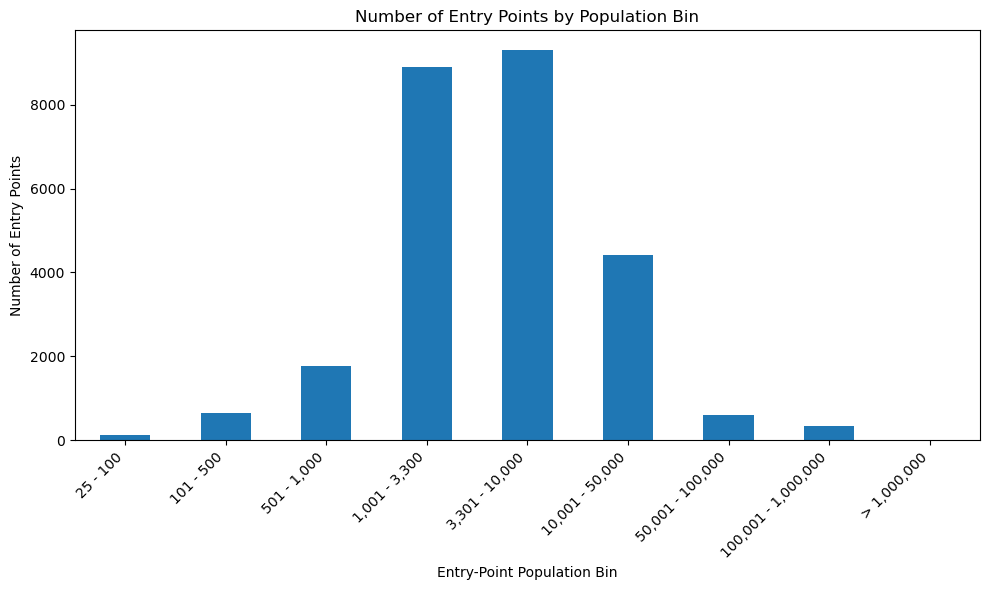

In [46]:
bin_order = [
    '25 - 100',
    '101 - 500',
    '501 - 1,000',
    '1,001 - 3,300',
    '3,301 - 10,000',
    '10,001 - 50,000',
    '50,001 - 100,000',
    '100,001 - 1,000,000',
    '> 1,000,000'
]

ep_bin_counts = (
    ep_table_final["Population_bin"]
    .value_counts()
    .reindex(bin_order, fill_value=0)
)

plt.figure(figsize=(10, 6))
ep_bin_counts.plot(kind="bar")

plt.xlabel("Entry-Point Population Bin")
plt.ylabel("Number of Entry Points")
plt.title("Number of Entry Points by Population Bin")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


This box-and-whisker plot shows how the number of entry points in a water system varies across different system population sizes. Each box summarizes how many entry points systems typically have within each population group, helping show that larger systems generally have more entry points than smaller systems.

In [47]:
pws_table = (
    ep_table_with_pop.groupby("PWSID")
    .agg(
        Population=("POPULATION_SERVED_COUNT", "first"),
        n_entry_points=("FacilityID", "nunique")
    )
    .reset_index()
)
pws_table

,PWSID,Population,n_entry_points
0,AK2110342,38526.0,2
1,AK2110601,10947.0,2
2,AK2120232,8937.0,1
3,AK2130075,9448.0,1
4,AK2210605,794.0,1
...,...,...,...
10150,WY5601569,580.0,1
10151,WY5680074,4300.0,1
10152,WY5680085,7675.0,1
10153,WY5680095,4514.0,1


In [48]:
pws_table["Population_bin"] = pws_table["Population"].apply(assign_pop_bin)
data = [
    pws_table.loc[pws_table["Population_bin"] == b, "n_entry_points"]
    for b in bin_order
]


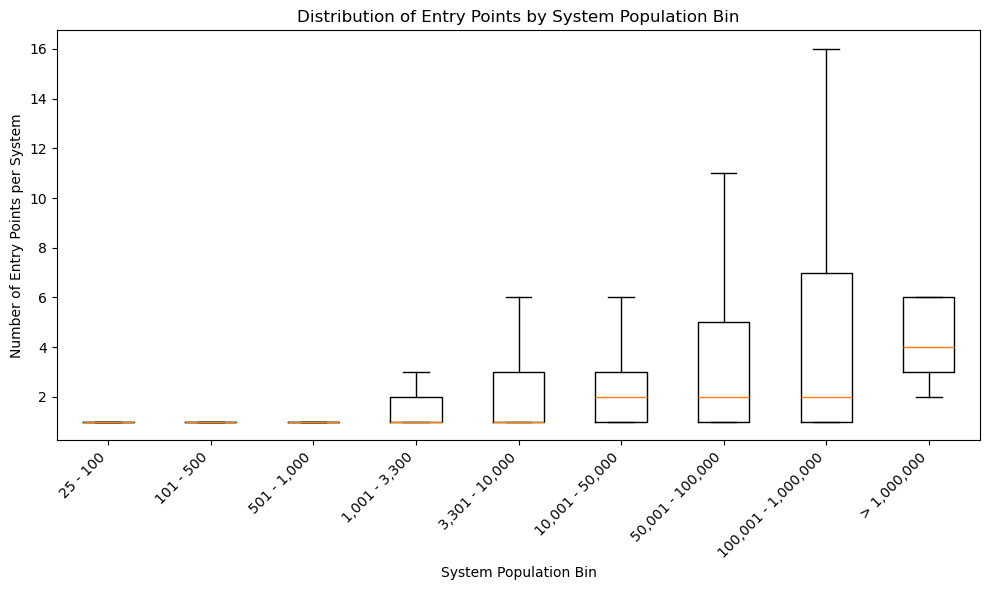

In [49]:
plt.figure(figsize=(10, 6))
plt.boxplot(data, tick_labels=bin_order, showfliers=False)

plt.xlabel("System Population Bin")
plt.ylabel("Number of Entry Points per System")
plt.title("Distribution of Entry Points by System Population Bin")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [50]:
ep_table_final.to_csv("ep_table.csv", index = False)